# 🧠 UNESA Knowledge Graph — Exploration Notebook

Interactive exploration of the UNESA Academic Knowledge Graph built by `src/kg/`.

**Prerequisites:** Run `kg_construction.ipynb` first to populate Neo4j and Weaviate.

---

## Cells Overview
1. **Setup & Connection** — Import from `src.kg`, connect to Neo4j
2. **Graph Statistics** — Node/edge counts, label distributions
3. **Co-authorship Network** — All author co-authorship pairs
4. **Semantic Entity Explorer** — Browse Methods, Models, Metrics, etc.
5. **Cross-Prodi Research Landscape** — Field × ProgramStudi heatmap
6. **Advanced Cypher Queries** — 10 pre-built analytical queries
7. **Weaviate Vector Search** — Semantic similarity search across 4 VDBs
8. **Graph Visualization** — Interactive pyvis network rendering

In [1]:
# ══════════════════════════════════════════════════════════════════════
# CELL 1: Setup & Connections
# ══════════════════════════════════════════════════════════════════════
import sys, os, logging, warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 50)

# Ensure project root is in path
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

logging.basicConfig(level=logging.INFO, format='%(levelname)-8s | %(message)s')
logger = logging.getLogger('kg_explorer')

# ── Import from src.kg ──
from src.kg.config import NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD, NEO4J_DATABASE
from src.kg.neo4j_writer import Neo4jKGWriter
from src.kg.ontology import ONTOLOGY, PRODI_FAKULTAS, get_valid_semantic_labels

# ── Connect to Neo4j ──
writer = Neo4jKGWriter()
print(f'\n✅ Connected to Neo4j: {NEO4J_URI} (db={NEO4J_DATABASE})')

# Helper: run Cypher and return DataFrame
def cypher(query, **params):
    """Run a Cypher query and return results as a DataFrame."""
    data = writer.run_query(query, **params)
    return pd.DataFrame(data) if data else pd.DataFrame()

print('🔧 Helper function `cypher(query)` is ready.')
print('📦 Ontology loaded:', len(ONTOLOGY['node_types']), 'node types,', len(ONTOLOGY['edge_types']), 'edge types')

INFO     | ✅ KG Config loaded (Neo4j: bolt://localhost:7687, DB: datascience, Weaviate: localhost:8081)
INFO     | ✅ Neo4jKGWriter connected to bolt://localhost:7687 (db=datascience)



✅ Connected to Neo4j: bolt://localhost:7687 (db=datascience)
🔧 Helper function `cypher(query)` is ready.
📦 Ontology loaded: 17 node types, 16 edge types


📊 Total Nodes: 215
📊 Total Edges: 226



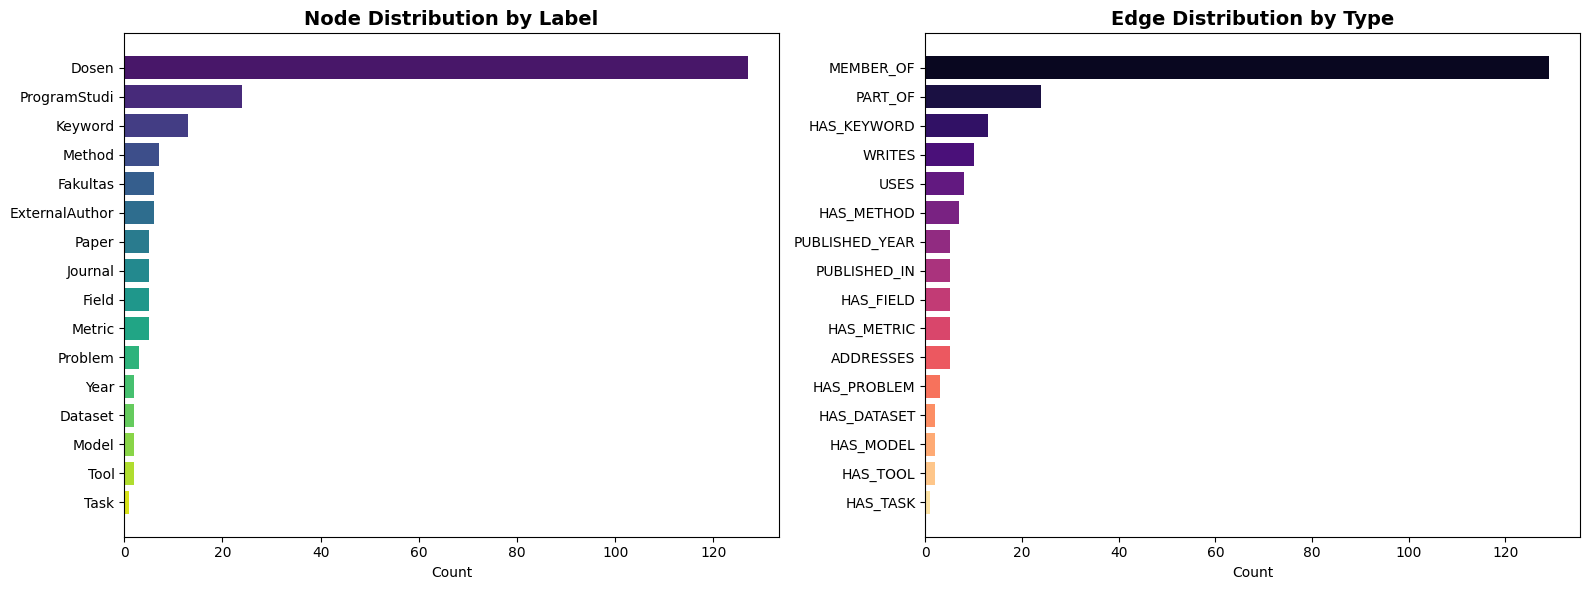

,Label,Count
0,Dosen,127
1,ProgramStudi,24
2,Keyword,13
3,Method,7
4,Fakultas,6
5,ExternalAuthor,6
6,Paper,5
7,Journal,5
8,Field,5
9,Metric,5


,Relationship,Count
0,MEMBER_OF,129
1,PART_OF,24
2,HAS_KEYWORD,13
3,WRITES,10
4,USES,8
5,HAS_METHOD,7
6,PUBLISHED_YEAR,5
7,PUBLISHED_IN,5
8,HAS_FIELD,5
9,HAS_METRIC,5


In [2]:
# ══════════════════════════════════════════════════════════════════════
# CELL 2: Graph Statistics Overview
# ══════════════════════════════════════════════════════════════════════
stats = writer.get_stats()

print(f"📊 Total Nodes: {stats['node_count']:,}")
print(f"📊 Total Edges: {stats['edge_count']:,}")
print()

# Node distribution
df_nodes = pd.DataFrame(
    list(stats['label_distribution'].items()),
    columns=['Label', 'Count']
).sort_values('Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Node chart
colors = sns.color_palette('viridis', len(df_nodes))
axes[0].barh(df_nodes['Label'], df_nodes['Count'], color=colors)
axes[0].set_title('Node Distribution by Label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Edge chart
df_edges = pd.DataFrame(
    list(stats['rel_distribution'].items()),
    columns=['Relationship', 'Count']
).sort_values('Count', ascending=False)

colors2 = sns.color_palette('magma', len(df_edges))
axes[1].barh(df_edges['Relationship'], df_edges['Count'], color=colors2)
axes[1].set_title('Edge Distribution by Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

display(df_nodes)
display(df_edges)

In [3]:
# ══════════════════════════════════════════════════════════════════════
# CELL 3: Co-authorship Network (Dosen + ExternalAuthor)
# ══════════════════════════════════════════════════════════════════════
# Finds ALL co-authorship pairs: Dosen-Dosen, Dosen-ExtAuthor, ExtAuthor-ExtAuthor.
# This works regardless of whether COLLABORATES_WITH edges have been derived.

df_collab = cypher("""
    MATCH (a1)-[:WRITES]->(p:Paper)<-[:WRITES]-(a2)
    WHERE a1 <> a2 AND elementId(a1) < elementId(a2)
    WITH a1, a2, COLLECT(DISTINCT p.title) AS papers, COUNT(DISTINCT p) AS paperCount
    OPTIONAL MATCH (a1)-[:MEMBER_OF]->(ps1:ProgramStudi)
    OPTIONAL MATCH (a2)-[:MEMBER_OF]->(ps2:ProgramStudi)
    RETURN labels(a1)[0] AS Type1, a1.name AS Author1, ps1.name AS Prodi1,
           labels(a2)[0] AS Type2, a2.name AS Author2, ps2.name AS Prodi2,
           paperCount AS Papers, papers AS SharedPapers
    ORDER BY Papers DESC
    LIMIT 20
""")

if not df_collab.empty:
    print(f'🤝 Top {len(df_collab)} Co-authorship Pairs:')
    display(df_collab)
    
    # Check for derived COLLABORATES_WITH edges (Dosen-Dosen only)
    df_cw = cypher('MATCH ()-[c:COLLABORATES_WITH]->() RETURN count(c) AS cnt')
    cw_count = df_cw['cnt'].iloc[0] if not df_cw.empty else 0
    print(f'\n📊 COLLABORATES_WITH derived edges: {cw_count}')
    if cw_count == 0:
        print('   ℹ️ Run writer.derive_collaborations() to create Dosen-Dosen edges.')
else:
    print('⚠️ No co-authorship pairs found in the graph.')
    print('   Ensure papers have multiple authors linked via WRITES edges.')

🤝 Top 15 Co-authorship Pairs:


,Type1,Author1,Prodi1,Type2,Author2,Prodi2,Papers,SharedPapers
0,ExternalAuthor,Agus Prihanto,None,ExternalAuthor,I Made Suartana,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...
1,ExternalAuthor,Ricky Eka Putra,None,ExternalAuthor,I Made Suartana,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...
2,ExternalAuthor,Anita Qoiriah,None,ExternalAuthor,I Made Suartana,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...
3,ExternalAuthor,Yuni Yamasari,None,ExternalAuthor,I Made Suartana,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...
4,ExternalAuthor,Aditya Prapanca,None,ExternalAuthor,I Made Suartana,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...
5,ExternalAuthor,Ricky Eka Putra,None,ExternalAuthor,Agus Prihanto,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...
6,ExternalAuthor,Anita Qoiriah,None,ExternalAuthor,Agus Prihanto,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...
7,ExternalAuthor,Yuni Yamasari,None,ExternalAuthor,Agus Prihanto,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...
8,ExternalAuthor,Aditya Prapanca,None,ExternalAuthor,Agus Prihanto,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...
9,ExternalAuthor,Anita Qoiriah,None,ExternalAuthor,Ricky Eka Putra,None,1,[Pelatihan Aplikasi Komputer untuk Penulisan Ilmiah di SMPN 1 Pagerwojo Tulu...



📊 COLLABORATES_WITH derived edges: 0
   ℹ️ Run writer.derive_collaborations() to create Dosen-Dosen edges.


In [4]:
# ══════════════════════════════════════════════════════════════════════
# CELL 4: Semantic Entity Explorer
# ══════════════════════════════════════════════════════════════════════

semantic_labels = get_valid_semantic_labels()
print(f'🔬 Semantic Entity Types: {semantic_labels}\n')

for label in sorted(semantic_labels):
    df_ent = cypher(f"""
        MATCH (e:{label})
        OPTIONAL MATCH (p:Paper)-[]->(e)
        RETURN e.name AS Entity, e.description AS Description,
               COUNT(DISTINCT p) AS PaperCount
        ORDER BY PaperCount DESC
        LIMIT 10
    """)
    
    if not df_ent.empty:
        print(f'\n── {label} ({len(df_ent)} shown) ──')
        display(df_ent)
    else:
        print(f'  {label}: (no entities found)')

🔬 Semantic Entity Types: {'Metric', 'Dataset', 'Tool', 'Task', 'Field', 'Method', 'Model', 'Problem', 'Innovation'}


── Dataset (2 shown) ──


,Entity,Description,PaperCount
0,SMPN 1 Pagerwojo,"Lokasi penelitian dan pelatihan, yaitu SMPN 1 Pagerwojo di Tulungagung, Jawa...",1
1,60-40 dataset split,60-40 dataset split adalah metode yang digunakan untuk membagi dataset,1



── Field (5 shown) ──


,Entity,Description,PaperCount
0,Penulisan Ilmiah,Bidang penulisan ilmiah yang menjadi fokus pelatihan,1
1,Ponorogo Subdistrict,Ponorogo Subdistrict adalah lokasi penelitian yang dilakukan,1
2,CV. SKM INDONESIA,Perusahaan yang bergerak di bidang industri kecil hingga menengah,1
3,SMKN 1 Kemlagi,Lokasi penelitian yang dilakukan,1
4,digital entertainment industry,Bidang industri hiburan digital yang memerlukan sistem rekomendasi yang akur...,1


  Innovation: (no entities found)

── Method (7 shown) ──


...

,Entity,Description,PaperCount
0,Teacher professionalism development,Masalah yang dihadapi dalam pengembangan profesionalisme guru,1
1,Malnutrition,Malnutrition adalah masalah kesehatan yang diatasi dalam penelitian ini,1
2,"inefficient, insecure, and inaccessible document management","Masalah pengelolaan dokumen yang tidak efisien, tidak aman, dan tidak dapat ...",1



── Task (1 shown) ──


,Entity,Description,PaperCount
0,Sistem Rekomendasi Film,Tugas yang dilakukan oleh sistem untuk memberikan rekomendasi film yang rele...,1



── Tool (2 shown) ──


,Entity,Description,PaperCount
0,PHP Framework Codeigniter,Framework PHP yang digunakan untuk mengembangkan sistem pengelolaan dokumen ...,1
1,E-Modul Berbasis Web,Alat pembelajaran yang dikembangkan dalam penelitian ini,1


ValueError: Unknown format code 'd' for object of type 'float'

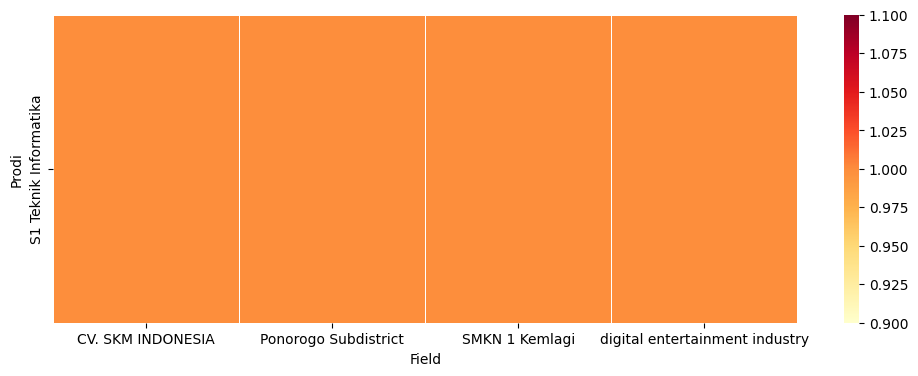

In [5]:
# ══════════════════════════════════════════════════════════════════════
# CELL 5: Cross-Prodi Research Landscape
# ══════════════════════════════════════════════════════════════════════
# NOTE: LLM curation may produce HAS_FIELD or IN_FIELD — we match both.

df_landscape = cypher("""
    MATCH (ps:ProgramStudi)<-[:MEMBER_OF]-(d:Dosen)-[:WRITES]->(p:Paper)-[:IN_FIELD|HAS_FIELD]->(f:Field)
    RETURN ps.name AS Prodi, f.name AS Field, COUNT(DISTINCT p) AS Papers
    ORDER BY Papers DESC
""")

if not df_landscape.empty:
    # Pivot for heatmap
    pivot = df_landscape.pivot_table(index='Prodi', columns='Field', values='Papers', fill_value=0)
    
    fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns)), max(4, len(pivot))))
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('Research Fields x Program Studi (Paper Count)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    # Fallback: show raw Field data to help debug
    df_fields = cypher('MATCH (p:Paper)-[r]->(f:Field) RETURN type(r) AS EdgeType, f.name AS Field, COUNT(p) AS Papers ORDER BY Papers DESC LIMIT 10')
    if not df_fields.empty:
        print('📊 Field data found (but no Dosen-Prodi path linked):')
        display(df_fields)
    else:
        print('⚠️ No Field nodes in graph. Run LLM curation (Step 5) with more papers.')

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 6: Advanced Analytical Queries
# ══════════════════════════════════════════════════════════════════════
# NOTE: LLM curation may produce variant edge names (e.g. HAS_FIELD vs IN_FIELD,
# HAS_PROBLEM vs ADDRESSES). We use Cypher pipe | to match both variants.

queries = {
    '1. Top Methods': '''
        MATCH (p:Paper)-[:HAS_METHOD]->(m:Method)
        RETURN m.name AS Method, COUNT(p) AS Papers
        ORDER BY Papers DESC LIMIT 10
    ''',
    '2. Top Models': '''
        MATCH (p:Paper)-[:HAS_MODEL]->(m:Model)
        RETURN m.name AS Model, COUNT(p) AS Papers
        ORDER BY Papers DESC LIMIT 10
    ''',
    '3. Most Productive Dosen': '''
        MATCH (d:Dosen)-[:WRITES]->(p:Paper)
        OPTIONAL MATCH (d)-[:MEMBER_OF]->(ps:ProgramStudi)
        RETURN d.name AS Dosen, ps.name AS Prodi, COUNT(p) AS Papers
        ORDER BY Papers DESC LIMIT 10
    ''',
    '4. Problem-Method Pairs': '''
        MATCH (p:Paper)-[:ADDRESSES|HAS_PROBLEM]->(pr:Problem)
        MATCH (p)-[:HAS_METHOD]->(m:Method)
        RETURN pr.name AS Problem, m.name AS Method, COUNT(p) AS Papers
        ORDER BY Papers DESC LIMIT 10
    ''',
    '5. Method-Tool Relationships (LLM-inferred)': '''
        MATCH (m:Method)-[r:USES]->(t:Tool)
        RETURN m.name AS Method, t.name AS Tool, r.description AS Context
        LIMIT 10
    ''',
    '6. Complex Papers (multi-method)': '''
        MATCH (p:Paper)-[:HAS_METHOD|HAS_MODEL]->(e)
        WITH p, COUNT(e) AS K, COLLECT(e.name) AS Entities
        WHERE K > 1
        RETURN p.title AS Paper, K AS EntityCount, Entities
        ORDER BY K DESC LIMIT 10
    ''',
    '7. Research Trends by Year': '''
        MATCH (p:Paper)-[:PUBLISHED_YEAR]->(y:Year)
        OPTIONAL MATCH (p)-[:IN_FIELD|HAS_FIELD]->(f:Field)
        RETURN y.value AS Year, f.name AS Field, COUNT(DISTINCT p) AS Papers
        ORDER BY Year DESC, Papers DESC
        LIMIT 20
    ''',
    '8. Expert Finder (shared problems)': '''
        MATCH (d1)-[:WRITES]->(:Paper)-[:ADDRESSES|HAS_PROBLEM]->(pr:Problem)
              <-[:ADDRESSES|HAS_PROBLEM]-(:Paper)<-[:WRITES]-(d2)
        WHERE d1 <> d2 AND elementId(d1) < elementId(d2)
        RETURN pr.name AS Problem, d1.name AS Expert1, d2.name AS Expert2
        LIMIT 10
    ''',
    '9. Dataset Usage': '''
        MATCH (p:Paper)-[:HAS_DATASET]->(ds:Dataset)
        RETURN ds.name AS Dataset, ds.description AS Description, COUNT(p) AS Papers
        ORDER BY Papers DESC LIMIT 10
    ''',
    '10. Innovation Landscape': '''
        MATCH (p:Paper)-[:PROPOSES]->(inn:Innovation)
        OPTIONAL MATCH (d)-[:WRITES]->(p)
        RETURN inn.name AS Innovation, inn.description AS Description,
               COLLECT(DISTINCT d.name) AS Researchers
        LIMIT 10
    ''',
}

for title, q in queries.items():
    df_result = cypher(q)
    if not df_result.empty:
        print(f'\n── {title} ──')
        display(df_result)
    else:
        print(f'\n── {title} ── (no results)')

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 7: Weaviate Vector Search (4 VDBs)
# ══════════════════════════════════════════════════════════════════════

try:
    import weaviate
    from src.kg.config import WEAVIATE_HOST, WEAVIATE_PORT
    
    wv_client = weaviate.connect_to_local(host=WEAVIATE_HOST, port=WEAVIATE_PORT)
    print(f'✅ Weaviate connected: {WEAVIATE_HOST}:{WEAVIATE_PORT}')
    
    # ── Search function ──
    def vdb_search(collection_name, query_text, limit=5):
        """Semantic search on a Weaviate collection."""
        col = wv_client.collections.get(collection_name)
        response = col.query.near_text(query=query_text, limit=limit)
        results = []
        for obj in response.objects:
            results.append(obj.properties)
        return pd.DataFrame(results)
    
    # ── Demo: Search across 4 VDBs ──
    DEMO_QUERY = 'machine learning classification'
    print(f'\n🔍 Demo search: "{DEMO_QUERY}"\n')
    
    for vdb in ['PaperChunk', 'EntityEmbedding', 'RelationshipEmbedding', 'ContentKeyword']:
        try:
            df_vdb = vdb_search(vdb, DEMO_QUERY, limit=3)
            if not df_vdb.empty:
                print(f'── {vdb} ──')
                display(df_vdb)
            else:
                print(f'── {vdb} ── (no results)')
        except Exception as e:
            print(f'── {vdb} ── ⚠️ Error: {e}')

except Exception as e:
    print(f'⚠️ Weaviate not available: {e}')
    print('   Weaviate is optional. Start it with: docker compose --profile vectordb up -d')

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 8: Interactive Graph Visualization (pyvis)
# ══════════════════════════════════════════════════════════════════════
import unicodedata, re as _re

def _sanitize(text):
    """Remove non-ASCII chars that break Windows charmap (cp1252) encoding."""
    if not text:
        return ''
    text = unicodedata.normalize('NFKD', str(text))
    return _re.sub(r'[^\x20-\x7E]', '', text)

try:
    from pyvis.network import Network
    
    # ── Fetch a subgraph (Paper + connected entities) ──
    subgraph_data = cypher("""
        MATCH (p:Paper)-[r]->(e)
        WITH p, r, e LIMIT 100
        RETURN p.title AS source_title, p.node_id AS source_id,
               labels(p)[0] AS source_label,
               type(r) AS rel_type,
               e.name AS target_name, e.node_id AS target_id,
               labels(e)[0] AS target_label
    """)
    
    if not subgraph_data.empty:
        # Color map for node types
        COLOR_MAP = {
            'Paper': '#4A90D9', 'Dosen': '#E67E22', 'ExternalAuthor': '#95A5A6',
            'Method': '#2ECC71', 'Model': '#9B59B6', 'Metric': '#E74C3C',
            'Dataset': '#1ABC9C', 'Problem': '#F39C12', 'Task': '#3498DB',
            'Field': '#27AE60', 'Tool': '#E91E63', 'Innovation': '#FF5722',
            'ProgramStudi': '#00BCD4', 'Fakultas': '#607D8B',
            'Journal': '#8BC34A', 'Year': '#FFC107', 'Keyword': '#9E9E9E',
        }
        
        net = Network(height='700px', width='100%', bgcolor='#222222',
                      font_color='white', notebook=True, cdn_resources='in_line')
        net.force_atlas_2based()
        
        added_nodes = set()
        for _, row in subgraph_data.iterrows():
            # Source (Paper)
            sid = str(row['source_id'])
            if sid not in added_nodes:
                title_short = _sanitize(str(row['source_title']))[:50] + '...'
                title_full = _sanitize(str(row['source_title']))
                net.add_node(sid, label=title_short, color=COLOR_MAP.get('Paper', '#999'),
                            shape='dot', size=15, title=title_full)
                added_nodes.add(sid)
            
            # Target (Entity)
            tid = str(row['target_id']) if row['target_id'] else None
            if tid and tid not in added_nodes:
                label = str(row['target_label'])
                tname = _sanitize(str(row['target_name']))
                net.add_node(tid, label=tname[:30],
                            color=COLOR_MAP.get(label, '#999'),
                            shape='dot', size=10,
                            title=f'[{label}] {tname}')
                added_nodes.add(tid)
            
            # Edge
            if tid:
                net.add_edge(sid, tid, title=str(row['rel_type']), color='#555555')
        
        # Save with explicit UTF-8 encoding (fixes Windows charmap error)
        output_dir = os.path.join(ROOT, 'data', 'kg_artifacts')
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, 'kg_exploration.html')
        
        # Generate HTML and write with UTF-8 to avoid cp1252 encoding issues
        html_content = net.generate_html()
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(html_content)
        
        print(f'✅ Interactive graph saved to: {output_path}')
        print(f'   Nodes: {len(added_nodes)}, Edges: {len(subgraph_data)}')
        
        # Display in notebook via IFrame
        from IPython.display import IFrame, display as ipy_display
        ipy_display(IFrame(output_path, width='100%', height=720))
    else:
        print('⚠️ No graph data available.')
        
except ImportError:
    print('⚠️ pyvis not installed. Run: pip install pyvis')
except Exception as e:
    import traceback; traceback.print_exc()
    print(f'⚠️ Visualization error: {e}')

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 9: Custom Cypher Playground
# ══════════════════════════════════════════════════════════════════════
# Use this cell to run any custom Cypher query interactively.
# Just edit the query string below and re-run the cell.

CUSTOM_QUERY = '''
MATCH (d:Dosen)-[:WRITES]->(p:Paper)
OPTIONAL MATCH (d)-[:MEMBER_OF]->(ps:ProgramStudi)
RETURN d.name AS Dosen, ps.name AS Prodi, COUNT(p) AS Papers
ORDER BY Papers DESC
LIMIT 15
'''

df_custom = cypher(CUSTOM_QUERY)
if not df_custom.empty:
    display(df_custom)
else:
    print('(no results)')

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 10: Cleanup
# ══════════════════════════════════════════════════════════════════════
writer.close()
try:
    wv_client.close()
except:
    pass
print('🔒 All connections closed.')